In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)

Shape: (284807, 31)

Columns:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [4]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [5]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 1081


In [6]:
class_counts = df["Class"].value_counts()
class_ratio = df["Class"].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", class_ratio)

Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class percentage:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


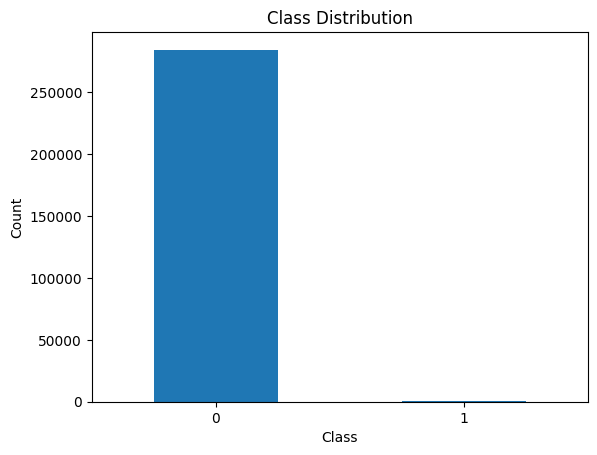

In [7]:
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


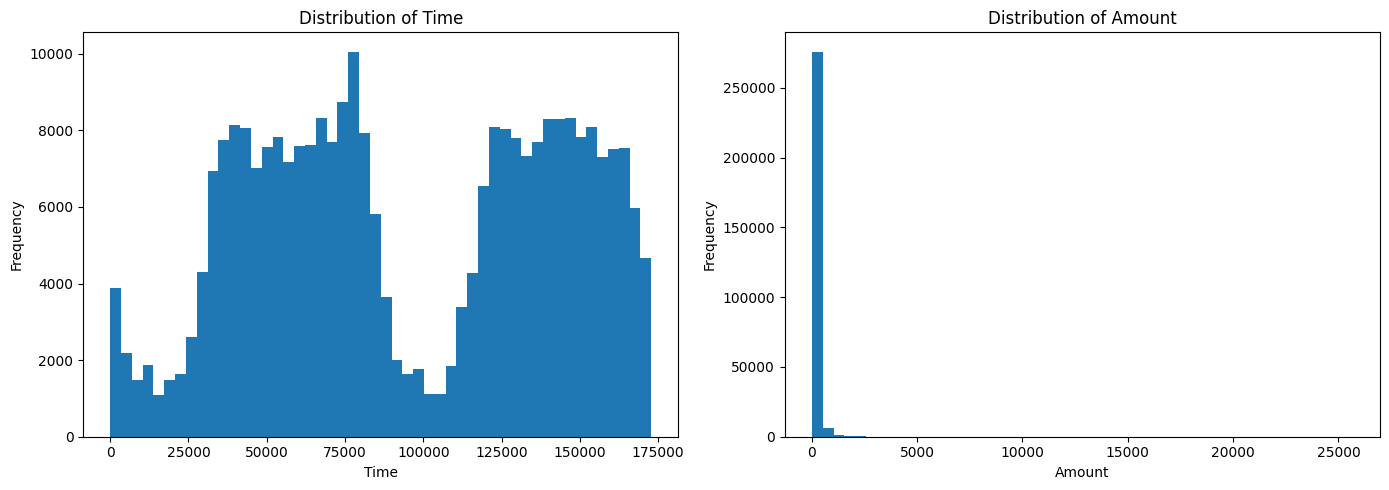

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Time"], bins=50)
axes[0].set_title("Distribution of Time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["Amount"], bins=50)
axes[1].set_title("Distribution of Amount")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [10]:
fraud = df[df["Class"] == 1]
non_fraud = df[df["Class"] == 0]

print("Fraud count:", len(fraud))
print("Non-fraud count:", len(non_fraud))

print("\nFraud Amount Stats:\n", fraud["Amount"].describe())
print("\nNon-Fraud Amount Stats:\n", non_fraud["Amount"].describe())

Fraud count: 492
Non-fraud count: 284315

Fraud Amount Stats:
 count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Non-Fraud Amount Stats:
 count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


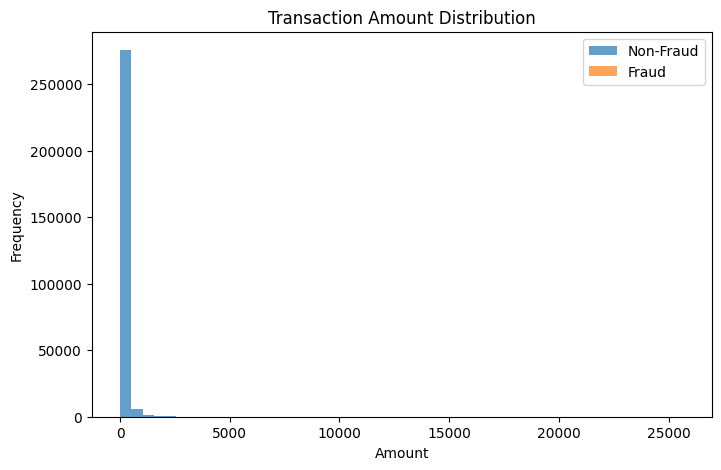

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(non_fraud["Amount"], bins=50, alpha=0.7, label="Non-Fraud")
plt.hist(fraud["Amount"], bins=50, alpha=0.7, label="Fraud")
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

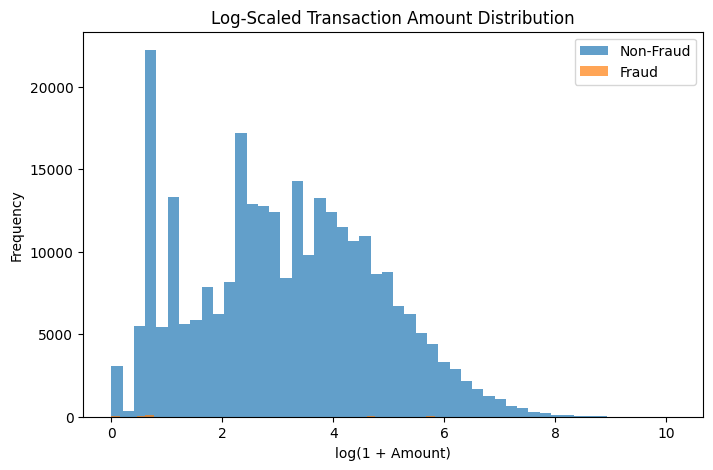

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(non_fraud["Amount"]), bins=50, alpha=0.7, label="Non-Fraud")
plt.hist(np.log1p(fraud["Amount"]), bins=50, alpha=0.7, label="Fraud")
plt.title("Log-Scaled Transaction Amount Distribution")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

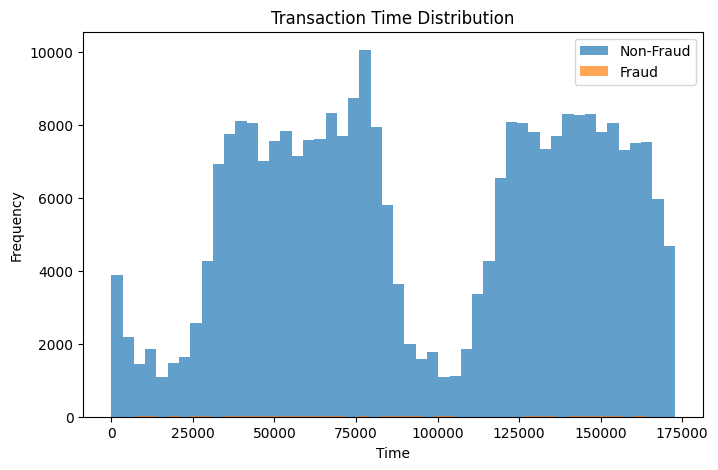

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(non_fraud["Time"], bins=50, alpha=0.7, label="Non-Fraud")
plt.hist(fraud["Time"], bins=50, alpha=0.7, label="Fraud")
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [14]:
df["Hour"] = (df["Time"] // 3600) % 24
df["Hour"] = df["Hour"].astype(int)

df[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0


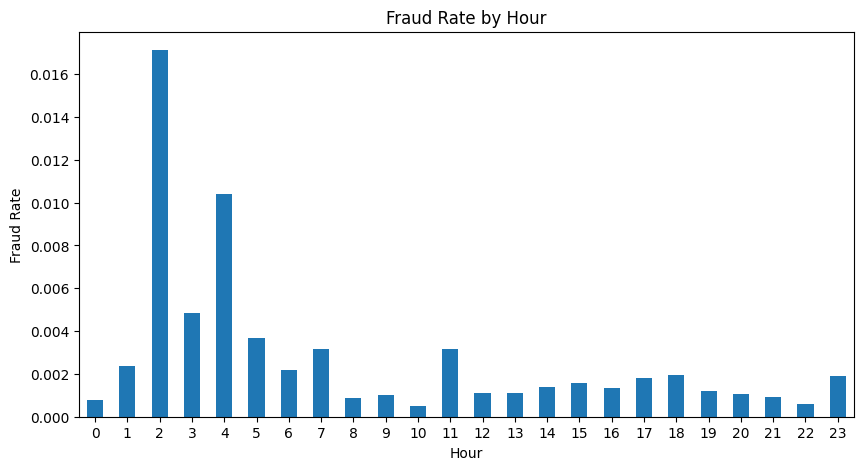

In [15]:
hourly_fraud_rate = df.groupby("Hour")["Class"].mean()

plt.figure(figsize=(10, 5))
hourly_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=0)
plt.show()

In [16]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 31)
y shape: (284807,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))

Train shape: (227845, 31)
Test shape: (56962, 31)

Train class distribution:
 Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Test class distribution:
 Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [18]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/creditcard_clean.csv", index=False)

In [19]:
df["LogAmount"] = np.log1p(df["Amount"])

In [20]:
df["Hour"] = (df["Time"] // 3600) % 24
df["Hour"] = df["Hour"].astype(int)

In [21]:
df["NightTransaction"] = df["Hour"].apply(lambda x: 1 if x <= 6 else 0)

In [22]:
X = df.drop(columns=["Class", "Amount"])
y = df["Class"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import matplotlib.pyplot as plt

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

C:\Users\jebap\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

In [28]:
print(classification_report(y_test, y_pred))

roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print("ROC AUC:", roc)
print("PR AUC:", pr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.71      0.77        98

    accuracy                           1.00     56962
   macro avg       0.92      0.86      0.89     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9423106186762831
PR AUC: 0.7154105751088728


In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [31]:
print(classification_report(y_test, rf_pred))

rf_roc = roc_auc_score(y_test, rf_prob)
rf_pr = average_precision_score(y_test, rf_prob)

print("ROC AUC:", rf_roc)
print("PR AUC:", rf_pr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9577506984082321
PR AUC: 0.858687284781258


In [32]:
gb_model = HistGradientBoostingClassifier()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, gb_pred))

gb_roc = roc_auc_score(y_test, gb_prob)
gb_pr = average_precision_score(y_test, gb_prob)

print("ROC AUC:", gb_roc)
print("PR AUC:", gb_pr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.55      0.78      0.64        98

    accuracy                           1.00     56962
   macro avg       0.77      0.89      0.82     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.8545490385940531
PR AUC: 0.5915677396931094


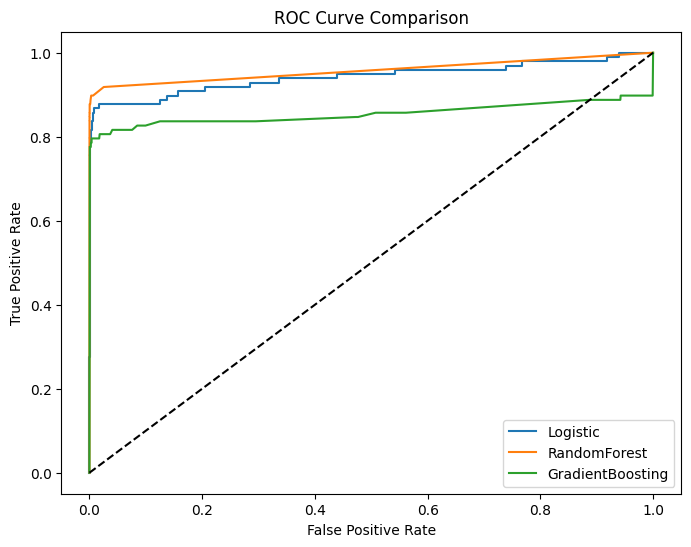

In [33]:
plt.figure(figsize=(8,6))

for name, prob in [
    ("Logistic", y_prob),
    ("RandomForest", rf_prob),
    ("GradientBoosting", gb_prob)
]:
    
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

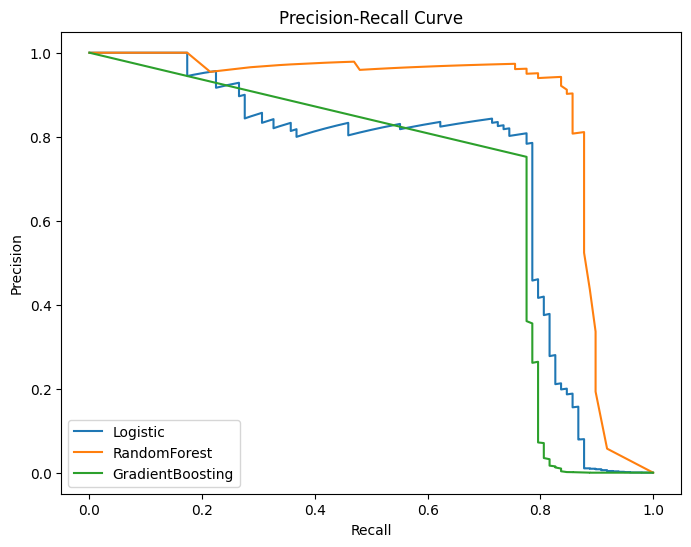

In [34]:
plt.figure(figsize=(8,6))

for name, prob in [
    ("Logistic", y_prob),
    ("RandomForest", rf_prob),
    ("GradientBoosting", gb_prob)
]:

    precision, recall, _ = precision_recall_curve(y_test, prob)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [35]:
sample_size = 15000

df_graph = df.sample(sample_size, random_state=42)

print(df_graph.shape)

(15000, 34)


In [36]:
graph_features = df_graph.drop(columns=["Class"])
graph_labels = df_graph["Class"].values

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_graph = scaler.fit_transform(graph_features)

In [38]:
from sklearn.neighbors import NearestNeighbors
import networkx as nx

In [39]:
k = 10

knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_graph)

distances, indices = knn.kneighbors(X_graph)

In [40]:
G = nx.Graph()

num_nodes = len(X_graph)

for i in range(num_nodes):
    G.add_node(i, label=graph_labels[i])

for i in range(num_nodes):
    for j in indices[i]:
        if i != j:
            G.add_edge(i, j)

In [41]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 15000
Edges: 100374


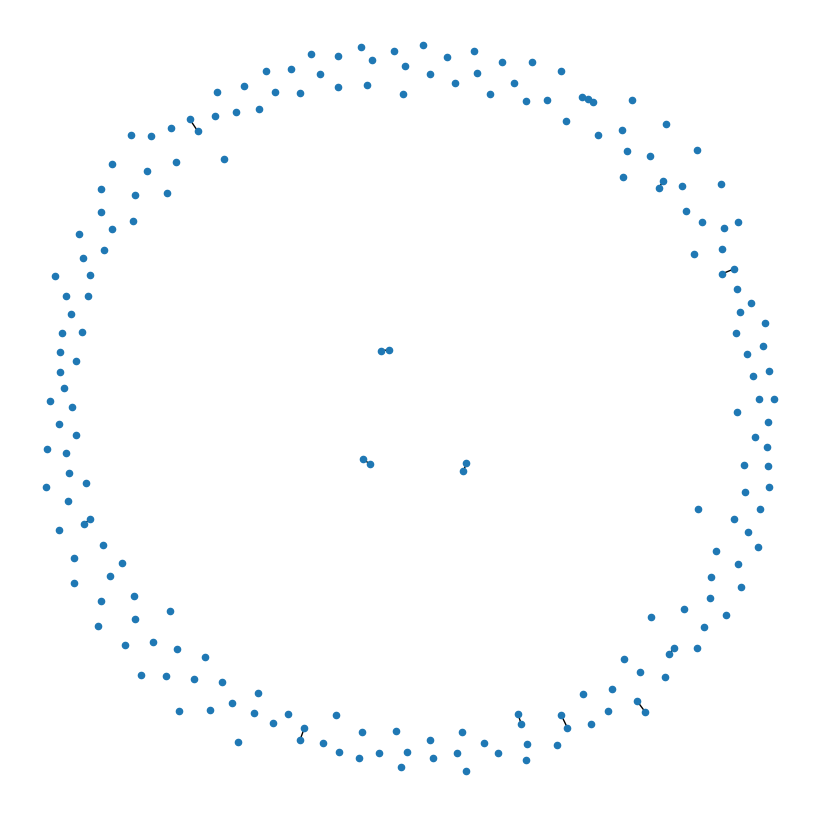

In [42]:
sub_nodes = list(G.nodes())[:200]
subgraph = G.subgraph(sub_nodes)

plt.figure(figsize=(8,8))
nx.draw(subgraph, node_size=20)
plt.show()

In [43]:
degrees = [d for _, d in G.degree()]
print("Min degree:", min(degrees))
print("Max degree:", max(degrees))
print("Average degree:", sum(degrees)/len(degrees))

Min degree: 9
Max degree: 39
Average degree: 13.3832


In [44]:
import torch
from torch_geometric.utils import from_networkx

In [45]:
pyg_data = from_networkx(G)
pyg_data

Data(edge_index=[2, 200748], label=[15000], num_nodes=15000)

In [46]:
pyg_data.x = torch.tensor(X_graph, dtype=torch.float)
pyg_data.y = torch.tensor(graph_labels, dtype=torch.long)

print(pyg_data)
print("Node feature shape:", pyg_data.x.shape)
print("Labels shape:", pyg_data.y.shape)

Data(edge_index=[2, 200748], label=[15000], num_nodes=15000, x=[15000, 33], y=[15000])
Node feature shape: torch.Size([15000, 33])
Labels shape: torch.Size([15000])


In [47]:
num_nodes = pyg_data.num_nodes

indices = np.arange(num_nodes)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=graph_labels
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

pyg_data.train_mask = train_mask
pyg_data.test_mask = test_mask

In [48]:
train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.2,
    random_state=42,
    stratify=graph_labels[train_idx]
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

pyg_data.train_mask = train_mask
pyg_data.val_mask = val_mask
pyg_data.test_mask = test_mask

print("Train nodes:", int(train_mask.sum()))
print("Val nodes:", int(val_mask.sum()))
print("Test nodes:", int(test_mask.sum()))

Train nodes: 9600
Val nodes: 2400
Test nodes: 3000


In [49]:
print("Train frauds:", int(pyg_data.y[pyg_data.train_mask].sum()))
print("Val frauds:", int(pyg_data.y[pyg_data.val_mask].sum()))
print("Test frauds:", int(pyg_data.y[pyg_data.test_mask].sum()))

Train frauds: 14
Val frauds: 3
Test frauds: 4


In [50]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

In [51]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.lin(x)
        return x

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pyg_data = pyg_data.to(device)

num_features = pyg_data.x.shape[1]

model = GraphSAGE(
    in_channels=num_features,
    hidden_channels=64,
    out_channels=2
).to(device)

class_counts = np.bincount(graph_labels)
class_weights = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]],
    dtype=torch.float
).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

In [53]:
def train():
    model.train()
    optimizer.zero_grad()
    
    out = model(pyg_data.x, pyg_data.edge_index)
    loss = criterion(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
    
    loss.backward()
    optimizer.step()
    return loss.item()

In [54]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate(mask):
    model.eval()
    out = model(pyg_data.x, pyg_data.edge_index)
    
    probs = torch.softmax(out, dim=1)[:, 1]
    preds = out.argmax(dim=1)
    
    y_true = pyg_data.y[mask].cpu().numpy()
    y_pred = preds[mask].cpu().numpy()
    y_prob = probs[mask].cpu().numpy()
    
    return y_true, y_pred, y_prob

In [55]:
best_val_pr = 0
best_state = None

for epoch in range(1, 51):
    loss = train()
    
    y_val, y_val_pred, y_val_prob = evaluate(pyg_data.val_mask)
    val_pr = average_precision_score(y_val, y_val_prob)
    
    if val_pr > best_val_pr:
        best_val_pr = val_pr
        best_state = model.state_dict()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val PR-AUC: {val_pr:.4f}")

Epoch 005 | Loss: 0.3253 | Val PR-AUC: 0.6389
Epoch 010 | Loss: 0.1150 | Val PR-AUC: 0.7500
Epoch 015 | Loss: 0.0590 | Val PR-AUC: 0.7500
Epoch 020 | Loss: 0.0420 | Val PR-AUC: 0.7500
Epoch 025 | Loss: 0.0143 | Val PR-AUC: 0.7500
Epoch 030 | Loss: 0.0209 | Val PR-AUC: 0.7500
Epoch 035 | Loss: 0.0267 | Val PR-AUC: 0.7500
Epoch 040 | Loss: 0.0074 | Val PR-AUC: 0.7500
Epoch 045 | Loss: 0.0154 | Val PR-AUC: 0.7500
Epoch 050 | Loss: 0.0367 | Val PR-AUC: 0.7500


In [56]:
model.load_state_dict(best_state)

y_test_true, y_test_pred, y_test_prob = evaluate(pyg_data.test_mask)

print(classification_report(y_test_true, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test_true, y_test_prob))
print("Test PR-AUC:", average_precision_score(y_test_true, y_test_prob))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2996
           1       0.13      0.75      0.22         4

    accuracy                           0.99      3000
   macro avg       0.57      0.87      0.61      3000
weighted avg       1.00      0.99      1.00      3000

Test ROC-AUC: 0.9950767690253671
Test PR-AUC: 0.7658730158730158


In [57]:
@torch.no_grad()
def get_all_node_scores():
    model.eval()
    out = model(pyg_data.x, pyg_data.edge_index)
    probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
    preds = out.argmax(dim=1).cpu().numpy()
    return probs, preds

all_scores, all_preds = get_all_node_scores()

In [58]:
df_graph = df_graph.copy().reset_index(drop=True)

df_graph["gnn_risk_score"] = all_scores
df_graph["gnn_pred_label"] = all_preds

df_graph[["gnn_risk_score", "gnn_pred_label", "Class"]].head()

,gnn_risk_score,gnn_pred_label,Class
0,1.000000,1,1
1,0.000021,0,0
2,0.000002,0,0
3,0.000018,0,0
4,0.000006,0,0


In [59]:
top_risky = df_graph.sort_values("gnn_risk_score", ascending=False).head(20)

top_risky[["Time", "Amount", "LogAmount", "Hour", "Class", "gnn_risk_score", "gnn_pred_label"]]

,Time,Amount,LogAmount,Hour,Class,gnn_risk_score,gnn_pred_label
10634,41870.0,1.00,0.693147,11,1,1.0,1
565,74262.0,311.28,5.743900,20,1,1.0,1
5100,27252.0,99.99,4.615022,7,1,1.0,1
6706,21177.0,89.99,4.510750,5,0,1.0,1
6368,59385.0,18.98,2.994732,16,1,1.0,1
7846,135314.0,84.28,4.445940,13,1,1.0,1
4640,56887.0,5.00,1.791759,15,1,1.0,1
6815,29207.0,89.99,4.510750,8,0,1.0,1
9203,85181.0,2.00,1.098612,23,1,1.0,1
9163,30047.0,89.99,4.510750,8,0,1.0,1


In [60]:
for k in [10, 20, 50, 100]:
    top_k = df_graph.sort_values("gnn_risk_score", ascending=False).head(k)
    frauds_in_top_k = top_k["Class"].sum()
    print(f"Top {k}: {frauds_in_top_k} frauds")

Top 10: 7 frauds
Top 20: 15 frauds
Top 50: 20 frauds
Top 100: 20 frauds


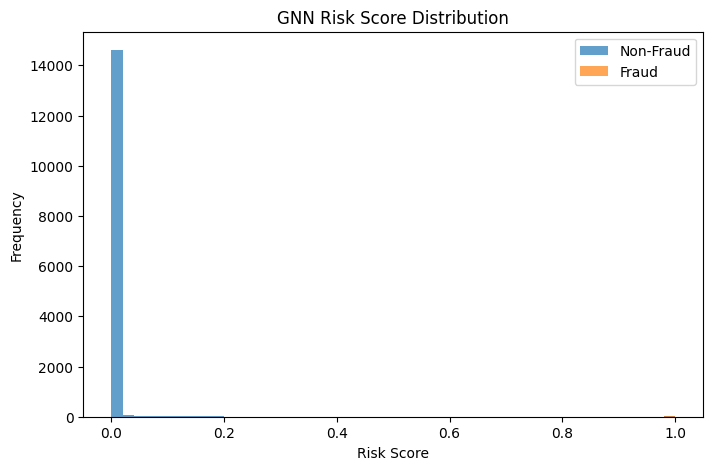

In [61]:
plt.figure(figsize=(8, 5))
plt.hist(df_graph[df_graph["Class"] == 0]["gnn_risk_score"], bins=50, alpha=0.7, label="Non-Fraud")
plt.hist(df_graph[df_graph["Class"] == 1]["gnn_risk_score"], bins=50, alpha=0.7, label="Fraud")
plt.title("GNN Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [62]:
risk_threshold = 0.8
suspicious_nodes = df_graph[df_graph["gnn_risk_score"] >= risk_threshold].index.tolist()

print("Suspicious nodes:", len(suspicious_nodes))

Suspicious nodes: 55


In [63]:
suspicious_subgraph = G.subgraph(suspicious_nodes)

print("Suspicious subgraph nodes:", suspicious_subgraph.number_of_nodes())
print("Suspicious subgraph edges:", suspicious_subgraph.number_of_edges())

Suspicious subgraph nodes: 55
Suspicious subgraph edges: 120


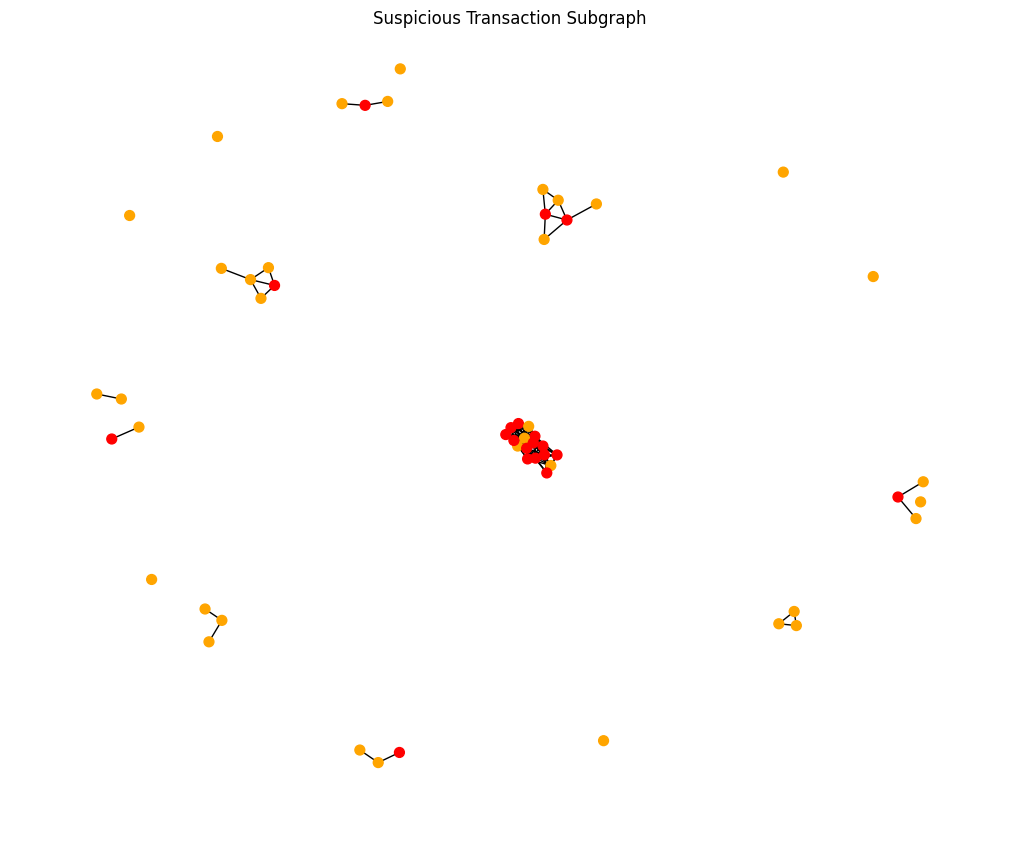

In [64]:
plt.figure(figsize=(10, 8))

if suspicious_subgraph.number_of_nodes() > 0:
    pos = nx.spring_layout(suspicious_subgraph, seed=42)
    
    node_colors = []
    for node in suspicious_subgraph.nodes():
        if df_graph.loc[node, "Class"] == 1:
            node_colors.append("red")
        else:
            node_colors.append("orange")
    
    nx.draw(
        suspicious_subgraph,
        pos,
        node_color=node_colors,
        node_size=50,
        with_labels=False
    )
    
    plt.title("Suspicious Transaction Subgraph")
    plt.show()
else:
    print("No suspicious nodes found at this threshold.")

In [65]:
components = list(nx.connected_components(suspicious_subgraph))
components = sorted(components, key=len, reverse=True)

print("Number of suspicious clusters:", len(components))
print("Largest cluster sizes:", [len(c) for c in components[:10]])

Number of suspicious clusters: 18
Largest cluster sizes: [17, 6, 5, 3, 3, 3, 3, 3, 2, 2]


In [66]:
if len(components) > 0:
    largest_cluster = list(components[0])
    cluster_df = df_graph.loc[largest_cluster, ["Time", "Amount", "Hour", "Class", "gnn_risk_score"]]
    cluster_df = cluster_df.sort_values("gnn_risk_score", ascending=False)
    print(cluster_df.head(20))

           Time  Amount  Hour  Class  gnn_risk_score
0       41505.0  364.19    11      1             1.0
4640    56887.0    5.00    15      1             1.0
6368    59385.0   18.98    16      1             1.0
7011    55311.0    0.83    15      1             1.0
7846   135314.0   84.28    13      1             1.0
6054   169351.0   77.89    23      1             1.0
8456   128519.0   93.35    11      1             1.0
10634   41870.0    1.00    11      1             1.0
9163    30047.0   89.99     8      0             1.0
5100    27252.0   99.99     7      1             1.0
3025   140308.0  592.90    14      1             1.0
6706    21177.0   89.99     5      0             1.0
9203    85181.0    2.00    23      1             1.0
565     74262.0  311.28    20      1             1.0
12824  135352.0  468.07    13      0             1.0
5756   160034.0    4.90    20      1             1.0
6815    29207.0   89.99     8      0             1.0


In [67]:
investigation_df = df_graph.copy()

investigation_df["cluster_id"] = -1

for i, component in enumerate(components):
    for node in component:
        investigation_df.loc[node, "cluster_id"] = i

In [68]:
degrees = dict(G.degree())

investigation_df["node_degree"] = investigation_df.index.map(degrees)

In [69]:
investigation_df.to_csv(
    "../outputs/fraud_investigation_dataset.csv",
    index=False
)

In [70]:
fraud_df = df[df["Class"] == 1].copy()
non_fraud_df = df[df["Class"] == 0].sample(12000, random_state=42).copy()

df_graph = pd.concat([fraud_df, non_fraud_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print(df_graph.shape)
print(df_graph["Class"].value_counts())

(12492, 34)
Class
0    12000
1      492
Name: count, dtype: int64


In [71]:
df_graph["LogAmount"] = np.log1p(df_graph["Amount"])
df_graph["Hour"] = ((df_graph["Time"] // 3600) % 24).astype(int)
df_graph["NightTransaction"] = df_graph["Hour"].apply(lambda x: 1 if x <= 6 else 0)

In [72]:
from sklearn.preprocessing import StandardScaler

graph_features = df_graph.drop(columns=["Class"])
graph_labels = df_graph["Class"].values

scaler = StandardScaler()
X_graph = scaler.fit_transform(graph_features)

In [73]:
import networkx as nx
from sklearn.neighbors import NearestNeighbors
from collections import defaultdict

G_hybrid = nx.Graph()

num_nodes = len(df_graph)

for i in range(num_nodes):
    G_hybrid.add_node(i, label=int(graph_labels[i]))

In [74]:
k = 8

knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_graph)

distances, indices = knn.kneighbors(X_graph)

for i in range(num_nodes):
    for j in indices[i]:
        if i != j:
            G_hybrid.add_edge(i, j, edge_type="knn")

In [75]:
hour_groups = df_graph.groupby("Hour").indices

same_hour_limit = 5

for hour, node_ids in hour_groups.items():
    node_ids = list(node_ids)
    for idx, i in enumerate(node_ids):
        neighbors = node_ids[max(0, idx - same_hour_limit): idx] + node_ids[idx + 1: idx + 1 + same_hour_limit]
        for j in neighbors:
            if i != j:
                G_hybrid.add_edge(i, j, edge_type="same_hour")

In [76]:
small_amt_nodes = df_graph[df_graph["Amount"] <= 5].index.tolist()

small_amount_limit = 10

small_amt_sorted = sorted(small_amt_nodes, key=lambda x: df_graph.loc[x, "Amount"])

for idx, i in enumerate(small_amt_sorted):
    amt_i = df_graph.loc[i, "Amount"]
    
    left = max(0, idx - small_amount_limit)
    right = min(len(small_amt_sorted), idx + small_amount_limit + 1)
    
    for j in small_amt_sorted[left:right]:
        if i == j:
            continue
        amt_j = df_graph.loc[j, "Amount"]
        if abs(amt_i - amt_j) <= 1.0:
            G_hybrid.add_edge(i, j, edge_type="small_amount")

In [77]:
time_sorted_nodes = sorted(range(num_nodes), key=lambda x: df_graph.loc[x, "Time"])

time_window = 300
time_neighbor_limit = 10

for idx, i in enumerate(time_sorted_nodes):
    time_i = df_graph.loc[i, "Time"]
    
    for offset in range(1, time_neighbor_limit + 1):
        if idx + offset >= len(time_sorted_nodes):
            break
        
        j = time_sorted_nodes[idx + offset]
        time_j = df_graph.loc[j, "Time"]
        
        if abs(time_j - time_i) <= time_window:
            G_hybrid.add_edge(i, j, edge_type="time_burst")
        else:
            break

In [78]:
print("Hybrid graph nodes:", G_hybrid.number_of_nodes())
print("Hybrid graph edges:", G_hybrid.number_of_edges())

degrees = [d for _, d in G_hybrid.degree()]
print("Min degree:", min(degrees))
print("Max degree:", max(degrees))
print("Average degree:", sum(degrees) / len(degrees))

Hybrid graph nodes: 12492
Hybrid graph edges: 276530
Min degree: 17
Max degree: 79
Average degree: 44.27313480627602


In [79]:
edge_type_counts = defaultdict(int)

for _, _, data in G_hybrid.edges(data=True):
    edge_type_counts[data.get("edge_type", "unknown")] += 1

print(dict(edge_type_counts))

{'knn': 63333, 'same_hour': 59732, 'time_burst': 121464, 'small_amount': 32001}


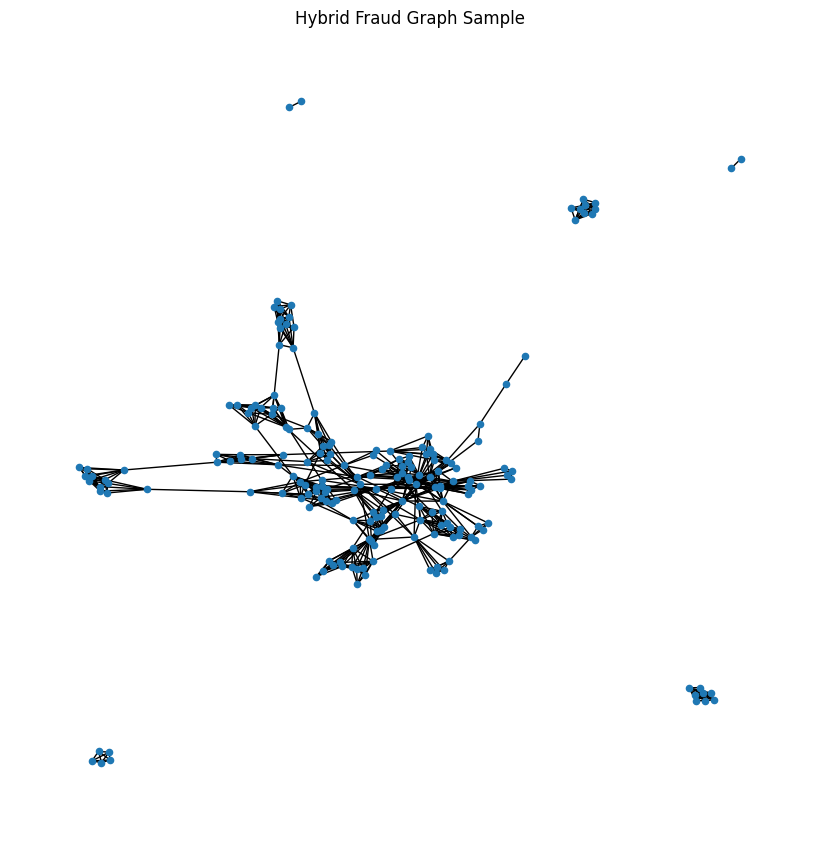

In [80]:
sub_nodes = list(G_hybrid.nodes())[:200]
subgraph = G_hybrid.subgraph(sub_nodes)

plt.figure(figsize=(8, 8))
nx.draw(subgraph, node_size=20)
plt.title("Hybrid Fraud Graph Sample")
plt.show()

In [81]:
import torch
from torch_geometric.utils import from_networkx

pyg_data = from_networkx(G_hybrid)

pyg_data.x = torch.tensor(X_graph, dtype=torch.float)
pyg_data.y = torch.tensor(graph_labels, dtype=torch.long)

print(pyg_data)
print("Node feature shape:", pyg_data.x.shape)
print("Labels shape:", pyg_data.y.shape)

Data(edge_index=[2, 553060], label=[12492], edge_type=[553060], num_nodes=12492, x=[12492, 33], y=[12492])
Node feature shape: torch.Size([12492, 33])
Labels shape: torch.Size([12492])


In [82]:
from sklearn.model_selection import train_test_split

num_nodes = pyg_data.num_nodes
indices = np.arange(num_nodes)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=graph_labels
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.2,
    random_state=42,
    stratify=graph_labels[train_idx]
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

pyg_data.train_mask = train_mask
pyg_data.val_mask = val_mask
pyg_data.test_mask = test_mask

print("Train frauds:", int(pyg_data.y[train_mask].sum()))
print("Val frauds:", int(pyg_data.y[val_mask].sum()))
print("Test frauds:", int(pyg_data.y[test_mask].sum()))

Train frauds: 315
Val frauds: 79
Test frauds: 98


In [83]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.lin(x)
        return x

In [84]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pyg_data = pyg_data.to(device)

model = GraphSAGE(
    in_channels=pyg_data.x.shape[1],
    hidden_channels=64,
    out_channels=2
).to(device)

class_counts = np.bincount(graph_labels)
class_weights = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]],
    dtype=torch.float
).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

In [85]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

def train():
    model.train()
    optimizer.zero_grad()
    out = model(pyg_data.x, pyg_data.edge_index)
    loss = criterion(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    out = model(pyg_data.x, pyg_data.edge_index)
    probs = torch.softmax(out, dim=1)[:, 1]
    preds = out.argmax(dim=1)

    y_true = pyg_data.y[mask].cpu().numpy()
    y_pred = preds[mask].cpu().numpy()
    y_prob = probs[mask].cpu().numpy()

    return y_true, y_pred, y_prob

In [86]:
best_val_pr = 0
best_state = None

for epoch in range(1, 61):
    loss = train()

    y_val, y_val_pred, y_val_prob = evaluate(pyg_data.val_mask)
    val_pr = average_precision_score(y_val, y_val_prob)

    if val_pr > best_val_pr:
        best_val_pr = val_pr
        best_state = model.state_dict()

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val PR-AUC: {val_pr:.4f}")

Epoch 005 | Loss: 0.2607 | Val PR-AUC: 0.9125
Epoch 010 | Loss: 0.1723 | Val PR-AUC: 0.9209
Epoch 015 | Loss: 0.1306 | Val PR-AUC: 0.8986
Epoch 020 | Loss: 0.1040 | Val PR-AUC: 0.9169
Epoch 025 | Loss: 0.0851 | Val PR-AUC: 0.9153
Epoch 030 | Loss: 0.0798 | Val PR-AUC: 0.9194
Epoch 035 | Loss: 0.0622 | Val PR-AUC: 0.9228
Epoch 040 | Loss: 0.0481 | Val PR-AUC: 0.9233
Epoch 045 | Loss: 0.0463 | Val PR-AUC: 0.9221
Epoch 050 | Loss: 0.0339 | Val PR-AUC: 0.9187
Epoch 055 | Loss: 0.0353 | Val PR-AUC: 0.9183
Epoch 060 | Loss: 0.0270 | Val PR-AUC: 0.9138


In [87]:
model.load_state_dict(best_state)

y_test_true, y_test_pred, y_test_prob = evaluate(pyg_data.test_mask)

print(classification_report(y_test_true, y_test_pred))
print("Hybrid Graph Test ROC-AUC:", roc_auc_score(y_test_true, y_test_prob))
print("Hybrid Graph Test PR-AUC:", average_precision_score(y_test_true, y_test_prob))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2401
           1       0.64      0.85      0.73        98

    accuracy                           0.98      2499
   macro avg       0.82      0.91      0.86      2499
weighted avg       0.98      0.98      0.98      2499

Hybrid Graph Test ROC-AUC: 0.9691327593094714
Hybrid Graph Test PR-AUC: 0.882778935252768


In [88]:
@torch.no_grad()
def get_all_node_scores():
    model.eval()
    out = model(pyg_data.x, pyg_data.edge_index)

    probs = torch.softmax(out, dim=1)[:,1].cpu().numpy()
    preds = out.argmax(dim=1).cpu().numpy()

    return probs, preds

all_scores, all_preds = get_all_node_scores()

In [89]:
df_graph = df_graph.copy().reset_index(drop=True)

df_graph["gnn_risk_score"] = all_scores
df_graph["gnn_prediction"] = all_preds

In [90]:
components = list(nx.connected_components(G_hybrid))
components = sorted(components, key=len, reverse=True)

In [91]:
df_graph["cluster_id"] = -1

for cluster_id, component in enumerate(components):
    for node in component:
        df_graph.loc[node, "cluster_id"] = cluster_id

In [92]:
degrees = dict(G_hybrid.degree())

df_graph["node_degree"] = df_graph.index.map(degrees)

In [93]:
fraud_neighbor_ratio = []

for node in G_hybrid.nodes():
    neighbors = list(G_hybrid.neighbors(node))
    
    if len(neighbors) == 0:
        fraud_neighbor_ratio.append(0)
    else:
        fraud_count = sum(df_graph.loc[n, "Class"] for n in neighbors)
        fraud_neighbor_ratio.append(fraud_count / len(neighbors))

df_graph["neighbor_fraud_ratio"] = fraud_neighbor_ratio

In [94]:
df_export = df_graph.rename(columns={
    "Class": "is_fraud",
    "Amount": "transaction_amount",
    "Hour": "transaction_hour"
})

In [95]:
df_export = df_export[
[
"Time",
"transaction_hour",
"transaction_amount",
"LogAmount",
"NightTransaction",
"is_fraud",
"gnn_risk_score",
"gnn_prediction",
"cluster_id",
"node_degree",
"neighbor_fraud_ratio"
]
]

In [96]:
def risk_bucket(score):
    
    if score >= 0.9:
        return "Very High"
    
    elif score >= 0.75:
        return "High"
    
    elif score >= 0.5:
        return "Medium"
    
    else:
        return "Low"

df_export["risk_level"] = df_export["gnn_risk_score"].apply(risk_bucket)

In [97]:
df_export.to_csv(
"../outputs/fraud_tableau_dataset.csv",
index=False
)

In [98]:
# ==============================
# Phase: LLM Fraud Explanations
# ==============================

In [99]:
!pip install groq


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
import os
os.environ["GROQ_API_KEY"] = "YOUR_API_KEY"

In [101]:
from groq import Groq

client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

In [102]:
chat_completion = client.chat.completions.create(
    messages=[
        {"role": "user", "content": "Say hello in one sentence."}
    ],
    model="llama-3.3-70b-versatile",
)

print(chat_completion.choices[0].message.content)

Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


In [103]:
def get_groq_explanation(prompt):
    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": "You are a fraud investigation assistant. Be concise, structured, and evidence-based."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        model="llama-3.3-70b-versatile",
    )
    return chat_completion.choices[0].message.content

In [105]:
def build_fraud_prompt(row):
    return f"""
You are a fraud investigation assistant.

Analyze this transaction and explain why it may be suspicious.

Transaction details:
- Time: {row['Time']}
- Hour of day: {row['Hour']}
- Amount: {row['Amount']}
- LogAmount: {row['LogAmount']:.4f}
- Night transaction: {row['NightTransaction']}
- GNN fraud risk score: {row['gnn_risk_score']:.4f}
- Model predicted fraud: {row['gnn_prediction']}
- Graph node degree: {row['node_degree']}
- Neighbor fraud ratio: {row['neighbor_fraud_ratio']:.4f}

Write the output in this format:

Risk Summary:
Why It Was Flagged:
Possible Fraud Pattern:
Recommended Investigator Action:
"""

In [107]:
top_cases = df_graph.sort_values("gnn_risk_score", ascending=False).head(10).copy()
top_cases.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,LogAmount,NightTransaction,gnn_risk_score,gnn_prediction,cluster_id,node_degree,neighbor_fraud_ratio
12454,57027.0,-2.335655,2.225380,-3.379450,2.178538,-3.568264,0.316814,-1.734948,1.449139,-1.980033,-5.711505,1.837215,-4.540342,0.747846,-6.284314,-0.128887,-3.563239,-7.368321,-2.692953,-0.450550,0.274027,0.785540,0.297412,0.308536,-0.598416,-0.121850,-0.491018,0.701606,0.206966,444.17,1,15,6.098456,0,1.0,1,0,41,0.341463
11285,102625.0,-4.221221,2.871121,-5.888716,6.890952,-3.404894,-1.154394,-7.739928,2.851363,-2.507569,-5.110728,5.350890,-9.299807,2.793140,-6.106552,-2.106947,-6.250629,-13.566325,-4.192780,0.510570,-0.227882,1.620591,1.567947,-0.578007,-0.059045,-1.829169,-0.072429,0.136734,-0.599848,7.59,1,4,2.150599,1,1.0,1,0,26,0.346154
1035,93860.0,-10.850282,6.727466,-16.760583,8.425832,-10.252697,-4.192171,-14.077086,7.168288,-3.683242,-15.239962,8.030708,-16.060306,0.270530,-14.952981,-0.241095,-11.866731,-15.486990,-5.748652,4.130031,-0.646818,2.541637,0.135535,-1.023967,0.406265,0.106593,-0.026232,-1.464630,-0.411682,78.00,1,2,4.369448,1,1.0,1,0,31,0.677419
11266,41305.0,-12.980943,6.720508,-13.455636,8.698610,-11.479552,-2.681519,-14.019291,8.218191,-7.930900,-12.695947,5.589362,-11.960866,1.538671,-9.887214,0.633979,-11.350244,-21.710188,-8.859452,3.629714,-0.843303,2.549628,-0.532228,-0.235096,0.673209,0.226598,-0.006168,-1.185696,-0.747361,59.68,1,11,4.105614,0,1.0,1,0,36,0.305556
47,133731.0,1.176633,3.141918,-6.140445,5.521821,1.768515,-1.727186,-0.932429,0.292797,-3.156827,-3.898240,4.776720,-4.152499,-0.472991,-10.258851,-0.533456,0.458139,0.167602,1.404311,-1.874015,0.329568,0.129372,-0.803021,-0.074098,-0.031084,0.375366,0.065897,0.488258,0.325872,0.00,1,13,0.000000,0,1.0,1,0,51,0.333333


In [109]:
prompt = build_fraud_prompt(top_cases.iloc[0])
print(prompt)


You are a fraud investigation assistant.

Analyze this transaction and explain why it may be suspicious.

Transaction details:
- Time: 57027.0
- Hour of day: 15.0
- Amount: 444.17
- LogAmount: 6.0985
- Night transaction: 0.0
- GNN fraud risk score: 1.0000
- Model predicted fraud: 1.0
- Graph node degree: 41.0
- Neighbor fraud ratio: 0.3415

Write the output in this format:

Risk Summary:
Why It Was Flagged:
Possible Fraud Pattern:
Recommended Investigator Action:



In [110]:
explanation = get_groq_explanation(prompt)
print(explanation)

Risk Summary:
The transaction has a high risk of being fraudulent, with a GNN fraud risk score of 1.0000 and a model predicted fraud probability of 1.0.

Why It Was Flagged:
The transaction was flagged due to its high fraud risk score and predicted fraud probability. Additionally, the neighbor fraud ratio of 0.3415 suggests that a significant proportion of similar transactions have been fraudulent in the past.

Possible Fraud Pattern:
The transaction may be part of a larger pattern of fraudulent activity, potentially involving a network of individuals or entities. The high graph node degree of 41.0 indicates that the transaction is connected to a large number of other transactions, which could be a sign of a complex fraud scheme.

Recommended Investigator Action:
The investigator should thoroughly review the transaction and its associated network of transactions to identify potential links to known fraudulent activity. They should also verify the identity of the individuals or entities

In [111]:
top_cases_small = top_cases.head(5).copy()

top_cases_small["llm_explanation"] = top_cases_small.apply(
    lambda row: get_groq_explanation(build_fraud_prompt(row)),
    axis=1
)

top_cases_small[["Amount","Hour","gnn_risk_score","llm_explanation"]]

,Amount,Hour,gnn_risk_score,llm_explanation
12454,444.17,15,1.0,Risk Summary:\nThe transaction has a high risk...
11285,7.59,4,1.0,Risk Summary:\nThe transaction has a high risk...
1035,78.00,2,1.0,Risk Summary:\nThe transaction has a high risk...
11266,59.68,11,1.0,Risk Summary:\nThe transaction has a high risk...
47,0.00,13,1.0,Risk Summary:\nThe transaction has been flagge...


In [112]:
top_cases_small.to_csv("../outputs/fraud_ai_explanations_groq.csv", index=False)

In [113]:
top_cases = df_graph.sort_values("gnn_risk_score", ascending=False).head(10).copy()

prompt = build_fraud_prompt(top_cases.iloc[0])
explanation = get_groq_explanation(prompt)
print(explanation)

Risk Summary:
The transaction has a high risk of being fraudulent, with a GNN fraud risk score of 1.0000 and a model predicted fraud probability of 1.0.

Why It Was Flagged:
The transaction was flagged due to its high fraud risk scores, high graph node degree (41.0), and a significant neighbor fraud ratio (0.3415), indicating potential connections to other fraudulent activities.

Possible Fraud Pattern:
The transaction may be part of a larger fraud scheme, potentially involving a network of related accounts or a money laundering operation, given the high neighbor fraud ratio and graph node degree.

Recommended Investigator Action:
Investigate the transaction further by reviewing the account history, analyzing the user's behavior, and verifying the transaction details to confirm whether it is legitimate or fraudulent. Additionally, consider analyzing the neighboring accounts and transactions to identify potential patterns or connections to other suspicious activities.


In [114]:
top_cases_small = top_cases.head(5).copy()

top_cases_small["llm_explanation"] = top_cases_small.apply(
    lambda row: get_groq_explanation(build_fraud_prompt(row)),
    axis=1
)

top_cases_small[["Amount", "Hour", "gnn_risk_score", "llm_explanation"]]

,Amount,Hour,gnn_risk_score,llm_explanation
12454,444.17,15,1.0,Risk Summary:\nThe transaction has a high risk...
11285,7.59,4,1.0,Risk Summary:\nThe transaction has a high risk...
1035,78.00,2,1.0,Risk Summary:\nThe transaction has a high risk...
11266,59.68,11,1.0,Risk Summary:\nThe transaction has a high risk...
47,0.00,13,1.0,Risk Summary:\nThe transaction has been flagge...


In [115]:
top_cases_small.to_csv("../outputs/fraud_ai_explanations_groq.csv", index=False)

In [116]:
df_final = df_graph.copy()
df_final["llm_explanation"] = ""

for idx, row in top_cases_small.iterrows():
    df_final.loc[idx, "llm_explanation"] = row["llm_explanation"]

df_final.to_csv("../outputs/fraud_tableau_with_explanations.csv", index=False)